In [19]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px

In [20]:
#quantitativas >> float, int
#qualitativas >> com hierarquia, sem hierarquia

In [21]:
census = pd.read_csv("census.csv")
census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [22]:
census.isnull().sum()

age               0
workclass         0
final-weight      0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loos      0
hour-per-week     0
native-country    0
income            0
dtype: int64

In [23]:
np.unique(census["income"], return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841], dtype=int64))

<Axes: xlabel='income', ylabel='count'>

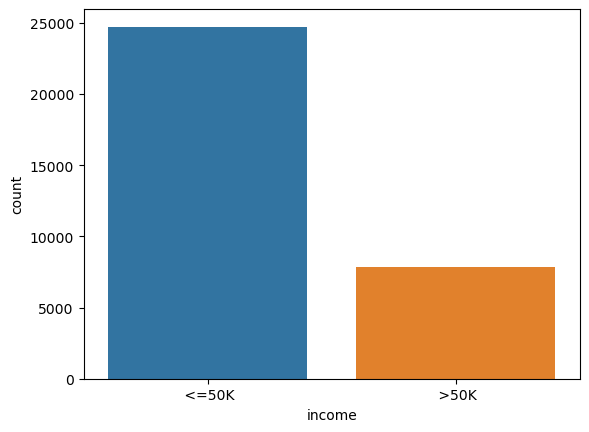

In [24]:
sns.countplot(x = census['income'])

(array([5570., 5890., 6048., 6163., 3967., 2591., 1595.,  496.,  174.,
          67.]),
 array([17. , 24.3, 31.6, 38.9, 46.2, 53.5, 60.8, 68.1, 75.4, 82.7, 90. ]),
 <BarContainer object of 10 artists>)

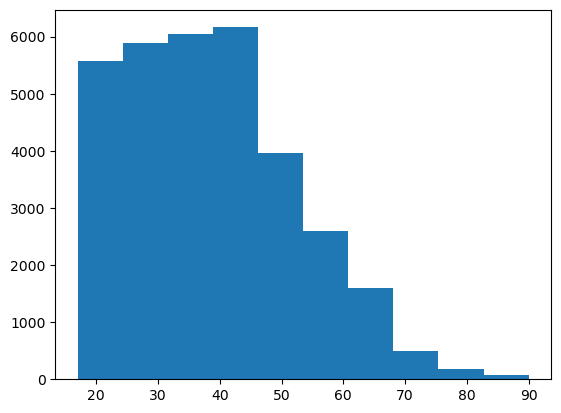

In [25]:
plt.hist(x=census['age'])

In [26]:
grafico = px.treemap(census, path=['workclass', 'age'])
grafico.show()

In [33]:
# grafico = px.parallel_categories(census, dimensions=['occupation', 'relationship'])
# grafico.show()

<h1>Label Enconding</h1>
> há order - hierarquia

In [36]:
x_census = census.iloc[:, 0:14].values
y_census = census.iloc[:, 14]

In [38]:
from sklearn.preprocessing import LabelEncoder
label_encoder_teste = LabelEncoder()
x_census[:,1]

array([' State-gov', ' Self-emp-not-inc', ' Private', ..., ' Private',
       ' Private', ' Self-emp-inc'], dtype=object)

In [39]:
teste = label_encoder_teste.fit_transform(x_census[:,1])
teste

array([7, 6, 4, ..., 4, 4, 5])

<h1>One-Hot Enconding</h1>
>não há ordem <br>
>num pequeno de categorias

In [40]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

onehotencoder_census = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [1,3,5,6,7,8,9,13])], remainder='passthrough')

In [44]:
x_census = onehotencoder_census.fit_transform(x_census)
x_census[0]

<1x108 sparse matrix of type '<class 'numpy.float64'>'
	with 13 stored elements in Compressed Sparse Row format>

<h2>StandardScaler</h2>
>padroniza dados <br>
>media = 0<br>
>transforma os dados em uma escala de -n até n

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_census = StandardScaler(with_mean=False) #so divide pelo desvio padrão - mean=False
x_census = scaler_census.fit_transform(x_census) 
x_census[0]

<1x108 sparse matrix of type '<class 'numpy.float64'>'
	with 13 stored elements in Compressed Sparse Row format>

In [51]:
from sklearn.model_selection import train_test_split
x_census_treinamento, x_census_teste, y_census_treinamento, y_census_teste = train_test_split(x_census, y_census.values, test_size=0.2, random_state=42)
x_census_treinamento.shape, x_census_teste.shape

# train_test_split(biX, y.values, test_size=0.2, random_state=42)

((26048, 108), (6513, 108))

In [52]:
import pickle #salva pythom em arquivo
with open('census.pkl', mode = 'wb') as f:
    pickle.dump([x_census_treinamento, y_census_treinamento, x_census_teste, y_census_teste], f)

<h1>Naive Bayes</h1>
>calcula proporções -> probabilidade de ser determinada classe <br>
>categorias independentes - sem correlação

<h1>Metricas Desempenho para Classificação</h1>

<h2>Acurária</h2>
>porcentagem de valores que foram classificados de forma correta<br>
>se proximo do valor verdadeiro -> acuracia alta <br>
<br>
<h2>Precisão</h2>
>Verifica somente valores que estão exatamente igual ao verdadeiro

In [53]:
from sklearn.naive_bayes import GaussianNB
import pickle

with open('census.pkl', 'rb') as f:
    x_census_treinamento, y_census_treinamento, x_census_teste, y_census_teste = pickle.load(f)
    
naive_census = GaussianNB()
naive_census.fit(x_census_treinamento.toarray(), y_census_treinamento)
previsoes = naive_census.predict(x_census_teste.toarray())
previsoes

array([' >50K', ' >50K', ' >50K', ..., ' >50K', ' >50K', ' >50K'],
      dtype='<U6')

*Calculo de Acurárica*

In [54]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_census_teste, previsoes)

0.4246890833717181

*Matriz de Confusão* 

0.4246890833717181

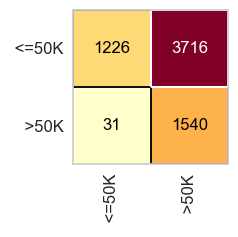

In [55]:
from yellowbrick.classifier import ConfusionMatrix
plt.figure(figsize=(2,2))
cm = ConfusionMatrix(naive_census)
cm.fit(x_census_treinamento.toarray(), y_census_treinamento)
cm.score(x_census_teste.toarray(), y_census_teste)